# Resume Skill Extraction and Job Matching Comparison

This notebook:
1. Extracts skills from resume PDFs using rule-based method
2. Matches extracted skills with job dataset using 3 models (TF-IDF, DistilBERT, SBERT)
3. Compares which model matches more accurately

## Install Required Packages
Install all libraries needed for PDF reading, text processing, and ML models.

In [3]:
# Install required libraries (only run once)
!pip -q install pandas numpy scikit-learn pdfplumber transformers torch sentence-transformers matplotlib
# !python -m spacy download en_core_web_sm -q

## Import Libraries and Helper Functions


In [5]:
import os, glob, re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PDF reading
import pdfplumber

# TF-IDF matching
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Transformer models
import torch
from transformers import AutoTokenizer, AutoModel

# Sentence-BERT
from sentence_transformers import SentenceTransformer


# Clean text - remove extra spaces and normalize line breaks
def clean_text(t: str) -> str:
    t = str(t)
    t = re.sub(r"\r", "\n", t)        # Windows line breaks to \n
    t = re.sub(r"[ \t]+", " ", t)     # Remove extra spaces/tabs
    t = re.sub(r"\n{2,}", "\n", t)    # Collapse multiple newlines
    # Remove PDF artifacts like (cid:127) which can hurt matching
    t = re.sub(r"\(cid:\d+\)", " ", t)  # Remove PDF character codes
    t = re.sub(r"cid:\d+", " ", t)      # Remove cid without parentheses
    return t.strip()


# Read PDF file and extract all text from all pages
def read_pdf(path: str) -> str:
    parts = []
    with pdfplumber.open(path) as pdf:
        for page in pdf.pages:
            parts.append(page.extract_text() or "")
    return clean_text("\n".join(parts))

## Skill Extraction from Resumes
Extract skills using improved rule-based method with multiple fallback strategies.

**Primary Method**: Extract from SKILLS section (best for structured resumes)

**Fallback Methods** (for resumes without SKILLS section):
- Method 2: Extract from Summary/Profile section
- Method 3: Extract technical keywords from entire resume
- Method 4: Extract from work experience section

In [7]:
# Headers that signal the end of skills section
STOP_HEADERS = [
    "work experience", "experience", "employment", "professional experience", "career history",
    "education", "academic", "qualifications",
    "projects", "academic projects",
    "certifications", "certification",
    "languages", "interests", "references"
]

# Keywords that indicate skills section 
SKILLS_HEADERS = [
    "skills", "skills summary", "technical skills", "key skills",
    "competencies", "tools", "technologies", "technology skills",
    "technical expertise", "core competencies", "skill set", "abilities",
    "programming languages", "software skills", "technical knowledge"
]

# Fallback sections to search for skills if SKILLS section not found
SUMMARY_HEADERS = [
    "summary", "professional summary", "profile", "objective",
    "career objective", "executive summary", "overview"
]

# Common technical terms/patterns that indicate skills (for fallback extraction)
TECHNICAL_KEYWORDS = [
    r'\b(python|java|javascript|typescript|c\+\+|c#|ruby|php|go|rust|swift|kotlin|scala)\b',
    r'\b(html|css|react|vue|angular|node|django|flask|spring|express)\b',
    r'\b(sql|mysql|postgresql|mongodb|redis|oracle|nosql)\b',
    r'\b(aws|azure|gcp|docker|kubernetes|jenkins|git|ci/cd)\b',
    r'\b(excel|powerpoint|word|outlook|tableau|power bi|salesforce)\b',
    r'\b(project management|agile|scrum|jira|confluence)\b'
]


# Normalize a line - remove extra spaces
def normalize_line(s: str) -> str:
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    return s


# Check if a line looks like a section header
def looks_like_header(line: str) -> bool:
    """
    Header detection: short line, mostly uppercase, or no sentence punctuation
    """
    l = normalize_line(line)
    if not l or len(l) > 45:
        return False

    # Check if mostly uppercase
    letters = re.sub(r"[^A-Za-z]+", "", l)
    if len(letters) >= 4:
        upper_ratio = sum(c.isupper() for c in letters) / len(letters)
        if upper_ratio > 0.75:
            return True

    # Short line without sentence punctuation
    if not re.search(r"[.!?]", l):
        return True

    return False


# Find a section block after header until next header
def find_section_block(text: str, header_keywords, max_lines=120, strict_header=True) -> str:
    """
    Find text block AFTER header line until next header appears.
    If strict_header=False, we're more lenient about what counts as a header
    (useful for SKILLS sections that might not be formatted as strict headers).
    """
    lines = [normalize_line(x) for x in text.split("\n") if normalize_line(x)]
    low_lines = [x.lower() for x in lines]

    start_idx = None

    # Find header line
    for i, ln in enumerate(low_lines):
        if any(k in ln for k in header_keywords):
            line_clean = lines[i].strip()
            
            if strict_header:
                # Strict mode: must look like a header
                if looks_like_header(lines[i]):
                    start_idx = i
                    break
            else:
                # Less strict mode: accept if keyword is standalone or line is short
                keyword_found = next((k for k in header_keywords if k in ln), None)
                if keyword_found:
                    # Check if keyword appears as a standalone word (not part of sentence)
                    keyword_pattern = r'\b' + re.escape(keyword_found) + r'\b'
                    is_standalone = bool(re.search(keyword_pattern, ln, re.I))
                    is_short = len(line_clean) < 80  # More lenient length
                    # Accept if standalone word OR short line OR looks like header
                    if is_standalone or is_short or looks_like_header(lines[i]):
                        start_idx = i
                        break

    if start_idx is None:
        return ""

    # Find where to stop (next header)
    end_idx = min(len(lines), start_idx + max_lines)
    for j in range(start_idx + 1, min(len(lines), start_idx + max_lines)):
        if looks_like_header(lines[j]):
            lj = low_lines[j]
            if any(h in lj for h in STOP_HEADERS):
                end_idx = j
                break

    # Return text after header line
    block = "\n".join(lines[start_idx + 1:end_idx]).strip()
    return block


# Generic/common phrases that aren't meaningful technical skills
GENERIC_PHRASES = {
    'documentation', 'problem solving', 'communication', 'teamwork', 'collaboration',
    'ability', 'skills', 'expertise', 'experience', 'knowledge', 'understanding',
    'developing', 'develop', 'including', 'sector', 'service', 'services',
    'models', 'model', 'foundation', 'foundations', 'required', 'related',
    'grant', 'education', 'research', 'scientists', 'cutting', 'edge', 'solutions',
    'scientific', 'performance', 'safety', 'quality', 'metrics',
    'production', 'technical', 'architecture', 'web', 'applications',
    'summary', 'objective', 'profile', 'history', 'career', 'professional'
}

def split_skills_from_line(line: str):
    """
    Extracts skills. Handles standard delimiters (comma, bullet) 
    AND space-separated Title Case lists (e.g. "Java Python SQL").
    """
    line = line.strip()
    if not line:
        return []

    # Clean bullets/numbering from start
    line = re.sub(r"^[•\-\*\u2022\d\.\)]+\s*", "", line).strip()
    
    # If "Category: Skills", take the right side
    if ":" in line and len(line.split(":")[0]) < 25: 
        _, right = line.split(":", 1)
        line = right.strip()

    parts = []
    
    # SPLIT STRATEGY
    # Case A: Explicit delimiters found (bullets, commas, pipes)
    if re.search(r"[,/|•\-\*]", line) or " and " in line:
        parts = re.split(r"[,/|•\-\*]|(?:\s+and\s+)", line)
        
    # Case B: No delimiters, but looks like a list of capitalized words?
    # ex: "Documentation Problem Solving Communication" -> Split by Capital letters
    else:
        # Regex: Find words that start with Uppercase, allow 1 space for things like "Data Science"
        # This catches "Java" and "Problem Solving" but splits "Java Python"
        candidates = re.findall(r'\b[A-Z][a-zA-Z\+\#]*\b(?: \b[A-Z][a-zA-Z\+\#]*\b)?', line)
        
        # If we found multiple Title Case terms in one line, assume it's a list
        if len(candidates) > 1:
            parts = candidates
        else:
            # Otherwise, treat the whole line as one item (ex: "Full Stack Developer")
            parts = [line]

    # FILTERING 
    cleaned = []
    for p in parts:
        p = p.strip().strip(" .;:-\"")
        if not p: continue
            
        low = p.lower()
        
        # A. Basic junk filters
        if re.search(r"@|http|www\.|(?:\(cid:)", low): continue # links/artifacts
        if re.fullmatch(r"[\d\W]+", p): continue # numbers only
        if len(p) < 2 or len(p) > 50: continue   # too short/long
        if len(p.split()) > 5: continue          # too much like a sentence
        
        # B. Generic Phrase Filter (Exact & Partial)
        # Check exact match
        if low in GENERIC_PHRASES: continue
        # Check plural (e.g., "communications")
        if low.endswith('s') and low[:-1] in GENERIC_PHRASES: continue
        
        # Check if it *contains* a generic phrase but isn't specific?
        # (Optional: keep strictly technical)
        
        cleaned.append(p)

    return cleaned

# Convert skills list to string for matching - ONLY from SKILLS section
def extract_skills_section(text: str, max_chars: int = 2000) -> str:
    """
    Extract skills ONLY from SKILLS section - no fallbacks to summary or other sections.
    This ensures we only match on actual skills, not summary text.
    Uses multiple extraction strategies for maximum robustness.
    Returns string for TF-IDF/BERT/SBERT matching.
    """
    # Find the skills block using SKILLS_HEADERS (case-insensitive matching)
    # Use strict_header=False for more lenient detection of SKILLS section
    skills_block = find_section_block(text, SKILLS_HEADERS, max_lines=120, strict_header=False)
    
    if not skills_block:
        return ""  # No SKILLS section found - return empty
    
    # Strategy 1: Try standard extraction
    skills = []
    for ln in skills_block.split("\n"):
        if not ln.strip():
            continue
        # Skip sub-headers like "TECHNICAL SKILLS", "SOFT SKILLS"
        if looks_like_header(ln) and len(ln.split()) <= 3:
            continue
        extracted = split_skills_from_line(ln)
        skills.extend(extracted)
    
    # Strategy 2: If we got very few skills, try more aggressive extraction
    if len(skills) < 3:
        # Try splitting long lines by capitalization patterns or common separators
        for ln in skills_block.split("\n"):
            if not ln.strip() or len(ln) < 5:
                continue
            # Skip headers
            if looks_like_header(ln) and len(ln.split()) <= 3:
                continue
            
            # For long lines without commas/slashes, try splitting by capital letters
            # (ex: "Python Java JavaScript" -> ["Python", "Java", "JavaScript"])
            if not re.search(r"[,/|]", ln) and len(ln.split()) > 3:
                # Try to find capitalized words that might be skills
                words = ln.split()
                # Look for sequences of capitalized words (likely skill names)
                current_skill = []
                for word in words:
                    word_clean = word.strip(".,;:-()[]")
                    if word_clean and (word_clean[0].isupper() or word_clean.isupper()):
                        if len(word_clean) >= 2:
                            current_skill.append(word_clean)
                    else:
                        if current_skill:
                            potential_skill = " ".join(current_skill)
                            if 2 <= len(potential_skill) <= 50 and len(current_skill) <= 4:
                                # Filter generic phrases
                                low = potential_skill.lower()
                                if low not in GENERIC_PHRASES:
                                    skills.append(potential_skill)
                            current_skill = []
                # Add last skill if exists
                if current_skill:
                    potential_skill = " ".join(current_skill)
                    if 2 <= len(potential_skill) <= 50 and len(current_skill) <= 4:
                        # Filter generic phrases
                        low = potential_skill.lower()
                        if low not in GENERIC_PHRASES:
                            skills.append(potential_skill)
            else:
                # Try standard extraction again
                extracted = split_skills_from_line(ln)
                if extracted:
                    skills.extend(extracted)
    
    # Strategy 3: If still empty, extract all reasonable words/phrases from the block
    # BUT filter out generic phrases aggressively
    if len(skills) == 0:
        # Last resort: extract capitalized sequences, but filter generic ones
        all_text = clean_text(skills_block)
        # Find capitalized sequences (potential skill names)
        cap_sequences = re.findall(r'\b[A-Z][a-z]+(?:\s+[A-Z][a-z]+){0,3}\b', all_text)
        for seq in cap_sequences:
            seq_clean = seq.strip(".,;:-()[]")
            if 2 <= len(seq_clean) <= 50 and len(seq_clean.split()) <= 4:
                # Filter out common non-skill words and generic phrases
                low = seq_clean.lower()
                if low not in ['the', 'and', 'or', 'for', 'with', 'from', 'this', 'that']:
                    if low not in GENERIC_PHRASES:
                        if not (low.endswith('s') and low[:-1] in GENERIC_PHRASES):
                            skills.append(seq_clean)
    
    # Remove duplicates (keep order) and clean up with FINAL generic phrase filter
    seen = set()
    out = []
    for s in skills:
        key = s.lower().strip()
        # Additional filtering for quality - EXCLUDE GENERIC PHRASES
        if key and len(key) >= 2 and len(key) <= 60:
            # Final check: filter out generic phrases
            if key in GENERIC_PHRASES:
                continue
            if key.endswith('s') and key[:-1] in GENERIC_PHRASES:
                continue
            if key.endswith('ing') and key[:-3] in GENERIC_PHRASES:
                continue
            
            if key not in seen:
                seen.add(key)
                # Clean skill string
                s_clean = s.strip() if isinstance(s, str) else str(s).strip()
                # Remove PDF artifacts
                s_clean = re.sub(r"\(cid:\d+\)", " ", s_clean)
                s_clean = re.sub(r"cid:\d+", " ", s_clean)
                s_clean = re.sub(r"\(\d+\)", " ", s_clean)
                s_clean = re.sub(r"\s+", " ", s_clean).strip()
                if s_clean and len(s_clean) >= 2 and len(s_clean) <= 60:
                    out.append(s_clean)
    
    # Return as cleaned text string (limited to max_chars)
    if not out:
        return ""
    
    result = clean_text(" ".join(out[:40]))[:max_chars]  # Increased from 30 to 40
    return result

In [8]:
resume_folder = "syn_resumes"

# Get all PDF files
resume_paths = sorted(glob.glob(os.path.join(resume_folder, "*.pdf")))

print("Total resumes found:", len(resume_paths))
if resume_paths:
    print("Example resume:", resume_paths[0])

# Read each resume and extract skills
rows = []
for p in resume_paths:
    full_text = read_pdf(p)
    skills_text = extract_skills_section(full_text)

    rows.append({
        "resume_path": p,
        "resume_full_text": full_text,
        "resume_skills_text": skills_text
    })

resumes_df = pd.DataFrame(rows)

# Show first few extracted skills
print("\nFirst few resumes and their extracted skills:")
resumes_df[["resume_path", "resume_skills_text"]].head(10)

Total resumes found: 29
Example resume: syn_resumes\Candidate_01_Data_Visualization_Expert.pdf

First few resumes and their extracted skills:


,resume_path,resume_skills_text
0,syn_resumes\Candidate_01_Data_Visualization_Ex...,Gender Equality Evaluation Women Gender Data E...
1,syn_resumes\Candidate_02_Technology_Integratio...,Sanitation Models Service Services Inclusive A...
2,syn_resumes\Candidate_03_Cloud_Architect.pdf,Web Applications Technical Architecture Knowle...
3,syn_resumes\Candidate_04_Data_Quality_Manager.pdf,Required Education Documents Qualifications Pr...
4,syn_resumes\Candidate_05_IT_Systems_Administra...,Level Intermediate Intermediate Level Performa...
5,syn_resumes\Candidate_07_Data_Analyst.pdf,Health Research Analytic Results Different Dis...
6,syn_resumes\Candidate_08_Deep_Learning.pdf,Plant Performance Safety Quality Metrics Produ...
7,syn_resumes\Candidate_09_Data_Scientist.pdf,Research Education Gs Veterans Level Specializ...
8,syn_resumes\Candidate_10_Data_Engineer.pdf,Engineering Education Required Eligibility Ser...
9,syn_resumes\Candidate_11_Cloud_Services_Develo...,Education Design Web Information Specialized W...


## Check Skills Extraction
See how many resumes have detected skills section.

In [10]:
# Check success rate
has_skills = (resumes_df["resume_skills_text"].str.len() > 0).mean() * 100
print(f"Resumes with detected SKILLS section: {has_skills:.1f}%")

# Debug: Test extraction on one resume to see what's happening
if len(resumes_df) > 0:
    test_idx = 0
    test_path = resumes_df.loc[test_idx, "resume_path"]
    test_text = resumes_df.loc[test_idx, "resume_full_text"]
    
    print(f"\n{'='*70}")
    print(f"DEBUG: Testing extraction on: {os.path.basename(test_path)}")
    print(f"{'='*70}")
    
    # Check if SKILLS section is found
    skills_block = find_section_block(test_text, SKILLS_HEADERS, max_lines=120, strict_header=False)
    print(f"\n1. Skills block found: {len(skills_block) > 0}")
    if skills_block:
        print(f"   Block length: {len(skills_block)} chars")
        print(f"   First 300 chars: {skills_block[:300]}")
        
        # Test splitting
        test_lines = skills_block.split("\n")[:5]  # First 5 lines
        print(f"\n2. Testing split_skills_from_line on first few lines:")
        for j, line in enumerate(test_lines):
            if line.strip():
                split_result = split_skills_from_line(line)
                print(f"   Line {j}: '{line[:60]}...' -> {split_result}")
    else:
        # Show what headers we're looking for vs what's in the text
        lines = [normalize_line(x) for x in test_text.split("\n") if normalize_line(x)]
        low_lines = [x.lower() for x in lines]
        print(f"\n2. Searching for SKILLS headers in text...")
        print(f"   Looking for: {SKILLS_HEADERS[:3]}...")
        
        # Show lines that might be headers
        possible_headers = []
        for i, ln in enumerate(low_lines[:50]):  # Check first 50 lines
            if any(k in ln for k in SKILLS_HEADERS):
                possible_headers.append((i, lines[i]))
        
        if possible_headers:
            print(f"   Found {len(possible_headers)} lines with SKILLS keywords:")
            for idx, line in possible_headers[:3]:
                print(f"      Line {idx}: '{line[:80]}'")
                print(f"         Looks like header: {looks_like_header(line)}")
        else:
            print(f"   No lines found containing SKILLS keywords in first 50 lines")
    
    # Show final result
    final_result = resumes_df.loc[test_idx, "resume_skills_text"]
    print(f"\n3. Final extracted skills text length: {len(final_result)}")
    if final_result:
        print(f"   First 200 chars: {final_result[:200]}")

# Show one example from the dataframe
if len(resumes_df) > 0:
    i = min(3, len(resumes_df) - 1)
    print(f"\n{'='*70}")
    print(f"Example Resume {i}: {os.path.basename(resumes_df.loc[i, 'resume_path'])}")
    print(f"{'='*70}")
    print("\nExtracted SKILLS section:\n", resumes_df.loc[i, "resume_skills_text"][:800])

Resumes with detected SKILLS section: 100.0%

DEBUG: Testing extraction on: Candidate_01_Data_Visualization_Expert.pdf

1. Skills block found: True
   Block length: 225 chars
   First 300 chars: Gender Equality Evaluation Women Gender Data Gender Equality Evidence Measurement Foundation
Empowerment Economic Research Policy Gaps Economic Empowerment Use Global Women Economic
Documentation Problem Solving Communication

2. Testing split_skills_from_line on first few lines:
   Line 0: 'Gender Equality Evaluation Women Gender Data Gender Equality...' -> ['Gender Equality', 'Evaluation Women', 'Gender Data', 'Gender Equality', 'Evidence Measurement']
   Line 1: 'Empowerment Economic Research Policy Gaps Economic Empowerme...' -> ['Empowerment Economic', 'Research Policy', 'Gaps Economic', 'Empowerment Use', 'Global Women', 'Economic']
   Line 2: 'Documentation Problem Solving Communication...' -> ['Documentation Problem', 'Solving Communication']

3. Final extracted skills text length: 198


## Load Job Dataset
Load CSV file with job descriptions for matching.

In [12]:
# Load job dataset CSV
jobs_path = "data/JobsDataset.csv"  

jobs_df = pd.read_csv(jobs_path)

print("Jobs rows:", len(jobs_df))
print("Columns:", jobs_df.columns.tolist())
jobs_df.head(3)


# Auto-detect which column contains job description
def pick_job_text_column(df):
    # Try common description column names
    candidates = ["Description", "description", "job_description", "Job Description", "desc"]
    for c in candidates:
        if c in df.columns:
            return c

    # Else choose the longest text column automatically
    text_cols = [c for c in df.columns if df[c].dtype == "object"]
    if not text_cols:
        raise ValueError("No text columns found in jobs_df.")
    return max(text_cols, key=lambda c: df[c].astype(str).str.len().mean())


JOB_TEXT_COL = pick_job_text_column(jobs_df)

# Choose title column if exists
if "Job Title" in jobs_df.columns:
    JOB_TITLE_COL = "Job Title"
elif "job_title" in jobs_df.columns:
    JOB_TITLE_COL = "job_title"
elif "title" in jobs_df.columns:
    JOB_TITLE_COL = "title"
else:
    JOB_TITLE_COL = None

# Clean job description texts
jobs_df = jobs_df.copy()
jobs_df[JOB_TEXT_COL] = jobs_df[JOB_TEXT_COL].astype(str).fillna("").apply(clean_text)

# Convert to list for faster processing
job_texts = jobs_df[JOB_TEXT_COL].tolist()

print("\nUsing job text col:", JOB_TEXT_COL)
print("Using job title col:", JOB_TITLE_COL)
print("Example job text length:", len(job_texts[0]) if job_texts else 0)

Jobs rows: 10000
Columns: ['ID', 'Query', 'Job Title', 'Description']

Using job text col: Description
Using job title col: Job Title
Example job text length: 5183


## Setup Matching Models
Initialize three models: TF-IDF (keyword-based), DistilBERT (contextual), and SBERT (sentence similarity).

## Data Preprocessing: Clean and prepare dataset
This step removes missing values, cleans whitespace, removes duplicates, and filters very short descriptions.

In [15]:
REQ_COLS = ["Query", "Job Title", "Description"]

# Drop missing values once 
before = len(jobs_df)
jobs_df = jobs_df.dropna(subset=REQ_COLS)
print(f"Removed {before - len(jobs_df)} rows with missing required fields")

# Basic whitespace cleanup 
def light_clean_text(t: str) -> str:
    t = str(t).replace("\r", "\n")
    t = re.sub(r"\s+", " ", t)
    return t.strip()

# Apply light cleaning to text columns
for col in REQ_COLS:
    jobs_df[col] = jobs_df[col].astype(str).apply(light_clean_text)

# Remove empty rows after cleaning
for col in REQ_COLS:
    before = len(jobs_df)
    jobs_df = jobs_df[jobs_df[col] != ""]
    if len(jobs_df) < before:
        print(f"Removed {before - len(jobs_df)} rows with empty {col}")

# Remove exact duplicates safely 
before = len(jobs_df)
jobs_df = jobs_df.drop_duplicates(subset=["Query", "Job Title", "Description"], keep="first").reset_index(drop=True)
print(f"Removed {before - len(jobs_df)} duplicate rows")

# filter super-short descriptions
MIN_DESC_CHARS = 30
if MIN_DESC_CHARS > 0:
    before = len(jobs_df)
    jobs_df = jobs_df[jobs_df["Description"].str.len() >= MIN_DESC_CHARS].reset_index(drop=True)
    print(f"Removed {before - len(jobs_df)} rows with descriptions < {MIN_DESC_CHARS} chars")

print(f"\nAfter preprocessing: {len(jobs_df)} rows")
print(f"Unique queries: {jobs_df['Query'].nunique()}")

job_texts = jobs_df[JOB_TEXT_COL].tolist()
print(f"Updated job_texts length: {len(job_texts)} (matches jobs_df)")

Removed 0 rows with missing required fields
Removed 461 duplicate rows
Removed 2 rows with descriptions < 30 chars

After preprocessing: 9537 rows
Unique queries: 25
Updated job_texts length: 9537 (matches jobs_df)


## Model 1: TF-IDF (keyword-based matching)

In [17]:
def rank_jobs_tfidf(query_text, job_texts, top_k=10):
    """
    Match using keyword similarity (TF-IDF vectors)
    """
    vec = TfidfVectorizer(stop_words="english")
    X = vec.fit_transform([query_text] + job_texts)  # First row = query, others = jobs
    sims = cosine_similarity(X[0], X[1:]).flatten()  # Cosine similarity
    top_idx = np.argsort(-sims)[:top_k]              # Highest similarity = best match
    return top_idx, sims[top_idx]

## Model 2: BERT (DistilBERT - smaller, faster version)
Uses contextual understanding instead of just keywords

In [19]:
device = torch.device("cpu")

BERT_NAME = "distilbert-base-uncased"
print("Loading BERT model...")
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)
bert_model = AutoModel.from_pretrained(BERT_NAME).to(device)
bert_model.eval()


@torch.no_grad()
def bert_embed(texts, max_length=128):
    """
    Convert text into embeddings using DistilBERT.
    Uses mean pooling across token embeddings.
    """
    encoded = bert_tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

    encoded = {k: v.to(device) for k, v in encoded.items()}
    out = bert_model(**encoded)

    # Token embeddings = last hidden state
    token_embeddings = out.last_hidden_state
    mask = encoded["attention_mask"].unsqueeze(-1)

    # Mean pooling
    summed = (token_embeddings * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return (summed / counts).cpu().numpy()

Loading BERT model...


## Model 3: SBERT (Sentence-BERT)
SBERT is specifically designed for semantic similarity tasks.

In [21]:
SBERT_NAME = "sentence-transformers/all-mpnet-base-v2"  
# This model has 768 dimensions and is optimized for semantic similarity tasks

print("Loading SBERT model (all-mpnet-base-v2 - higher accuracy)...")
sbert = SentenceTransformer(SBERT_NAME)
EXPECTED_SBERT_DIM = 768  # all-mpnet-base-v2 produces 768-dimensional embeddings

def sbert_embed(texts):
    # For better results with skill matching, we can process skills at sentence level
    if isinstance(texts, str):
        texts = [texts]
    
    return sbert.encode(texts, convert_to_numpy=True, normalize_embeddings=True, 
                       show_progress_bar=False)

Loading SBERT model (all-mpnet-base-v2 - higher accuracy)...


## Precompute Job Embeddings
Pre-calculate job embeddings once to make matching super fast later.
If embeddings already exist, just load them from cache.

In [23]:
# Cache file paths
BERT_EMB_PATH = "job_vecs_bert.npy"
SBERT_EMB_PATH = "job_vecs_sbert.npy"


# BERT job embeddings (cached) 
# Validate cache size matches current job_texts (after preprocessing)
job_vecs_bert = None
if os.path.exists(BERT_EMB_PATH):
    cached_bert = np.load(BERT_EMB_PATH)
    if cached_bert.shape[0] == len(job_texts):
        job_vecs_bert = cached_bert
        print("✓ Loaded cached BERT embeddings:", job_vecs_bert.shape)
    else:
        print(f"⚠ Cached BERT embeddings size mismatch!")
        print(f"   Expected: {len(job_texts)} jobs, Found: {cached_bert.shape[0]} jobs")
        print(f"   Deleting old cache and recomputing...")
        os.remove(BERT_EMB_PATH)

if job_vecs_bert is None:
    print("Computing BERT embeddings for all jobs...")
    BERT_BATCH = 16
    vecs = []
    for i in range(0, len(job_texts), BERT_BATCH):
        batch = job_texts[i:i+BERT_BATCH]
        vecs.append(bert_embed(batch, max_length=128))
        if i % (BERT_BATCH * 50) == 0:
            print(f"BERT processed: {i} / {len(job_texts)}")

    job_vecs_bert = np.vstack(vecs)
    np.save(BERT_EMB_PATH, job_vecs_bert)
    print("✓ Saved BERT embeddings:", job_vecs_bert.shape)


# SBERT job embeddings (cached) 

FORCE_RECOMPUTE_SBERT = True 

job_vecs_sbert = None
if os.path.exists(SBERT_EMB_PATH) and not FORCE_RECOMPUTE_SBERT:
    job_vecs_sbert = np.load(SBERT_EMB_PATH)
    cached_shape = job_vecs_sbert.shape
    cached_dim = cached_shape[1] if len(cached_shape) > 1 else None
    
    # Validate: must have correct number of jobs AND correct embedding dimension
    if cached_shape[0] != len(job_texts) or cached_dim != EXPECTED_SBERT_DIM:
        print(f" WARNING: Cached embeddings invalid!")
        print(f"   Expected: ({len(job_texts)}, {EXPECTED_SBERT_DIM})")
        print(f"   Found: {cached_shape}")
        print(f"   Deleting old cache and recomputing...")
        os.remove(SBERT_EMB_PATH)
        job_vecs_sbert = None
    else:
        print(f"✓ Loaded cached SBERT embeddings: {job_vecs_sbert.shape}")
        print(f"✓ Cache is valid for model: {SBERT_NAME}")
elif FORCE_RECOMPUTE_SBERT and os.path.exists(SBERT_EMB_PATH):
    print(f" FORCE RECOMPUTE: Deleting old cache to use upgraded model {SBERT_NAME}...")
    print(f"   Old cache will be replaced with embeddings from {SBERT_NAME} ({EXPECTED_SBERT_DIM} dimensions)")
    os.remove(SBERT_EMB_PATH)
    job_vecs_sbert = None

# Recompute if cache doesn't exist or was invalid
if job_vecs_sbert is None:
    
    SBERT_BATCH = 64  # Smaller batch for larger model
    vecs = []
    start_time = time.time()
    for i in range(0, len(job_texts), SBERT_BATCH):
        batch = job_texts[i:i+SBERT_BATCH]
        vecs.append(sbert_embed(batch))
        if i % (SBERT_BATCH * 10) == 0 or i + SBERT_BATCH >= len(job_texts):
            elapsed = time.time() - start_time
            rate = (i + SBERT_BATCH) / elapsed if elapsed > 0 else 0
            remaining = (len(job_texts) - i - SBERT_BATCH) / rate if rate > 0 else 0
            print(f"SBERT processed: {min(i + SBERT_BATCH, len(job_texts))} / {len(job_texts)} "
                  f"({min(i + SBERT_BATCH, len(job_texts))/len(job_texts)*100:.1f}%) - "
                  f"ETA: {remaining/60:.1f} min")

    job_vecs_sbert = np.vstack(vecs)
    np.save(SBERT_EMB_PATH, job_vecs_sbert)
    total_time = time.time() - start_time
    print(f"\n{'='*70}")
    print(f"✓ Saved SBERT embeddings: {job_vecs_sbert.shape}")
    print(f"✓ Cache file: {SBERT_EMB_PATH}")
    print(f"✓ Total time: {total_time/60:.1f} minutes")
    print(f"{'='*70}\n")

Computing BERT embeddings for all jobs...
BERT processed: 0 / 9537
BERT processed: 800 / 9537
BERT processed: 1600 / 9537
BERT processed: 2400 / 9537
BERT processed: 3200 / 9537
BERT processed: 4000 / 9537
BERT processed: 4800 / 9537
BERT processed: 5600 / 9537
BERT processed: 6400 / 9537
BERT processed: 7200 / 9537
BERT processed: 8000 / 9537
BERT processed: 8800 / 9537
✓ Saved BERT embeddings: (9537, 768)
SBERT processed: 64 / 9537 (0.7%) - ETA: 56.3 min
SBERT processed: 704 / 9537 (7.4%) - ETA: 50.9 min
SBERT processed: 1344 / 9537 (14.1%) - ETA: 47.3 min
SBERT processed: 1984 / 9537 (20.8%) - ETA: 43.5 min
SBERT processed: 2624 / 9537 (27.5%) - ETA: 39.6 min
SBERT processed: 3264 / 9537 (34.2%) - ETA: 35.7 min
SBERT processed: 3904 / 9537 (40.9%) - ETA: 32.0 min
SBERT processed: 4544 / 9537 (47.6%) - ETA: 28.4 min
SBERT processed: 5184 / 9537 (54.4%) - ETA: 24.7 min
SBERT processed: 5824 / 9537 (61.1%) - ETA: 21.1 min
SBERT processed: 6464 / 9537 (67.8%) - ETA: 17.4 min
SBERT proce

## Fast Job Ranking Functions

In [25]:
# Fast ranking using pre-computed embeddings

def rank_jobs_bert_fast(query_text, job_vecs, top_k=10):
    """
    Match using BERT - compute query embedding then compare with pre-computed job embeddings
    """
    qv = bert_embed([query_text], max_length=128)[0].reshape(1, -1)
    sims = cosine_similarity(qv, job_vecs).flatten()
    top_idx = np.argsort(-sims)[:top_k]
    return top_idx, sims[top_idx]

def rank_jobs_sbert_fast(query_text, job_vecs, top_k=10):
    """
    Match using SBERT - optimized for better semantic matching.
    
    Improvements for better accuracy:
    1. Enhanced text preprocessing for short skill lists
    2. Uses cosine_similarity for better numerical stability
    3. Validates embedding dimensions match
    """
    # Enhanced preprocessing for SBERT - ensure clean text
    query_clean = clean_text(query_text)
    
    # Generate embedding
    qv = sbert_embed([query_clean])[0].reshape(1, -1)
    
    # Validate dimensions match (safety check)
    if qv.shape[1] != job_vecs.shape[1]:
        raise ValueError(
            f"Dimension mismatch! Query embedding: {qv.shape[1]}, "
            f"Job embeddings: {job_vecs.shape[1]}. "
            f"Please delete cache file and recompute embeddings with current model."
        )
    
    # Use cosine_similarity for better numerical stability
    # (even though normalized, cosine_similarity handles edge cases better)
    sims = cosine_similarity(qv, job_vecs).flatten()
    top_idx = np.argsort(-sims)[:top_k]
    return top_idx, sims[top_idx]

## Test Matching on One Resume
Try matching one resume's skills with top-10 jobs using all three models.

In [27]:
# Choose any resume index
RESUME_IDX = 2  

if RESUME_IDX < len(resumes_df):
    resume_path = resumes_df.loc[RESUME_IDX, "resume_path"]
    skills_text = resumes_df.loc[RESUME_IDX, "resume_skills_text"]

    print("Resume:", resume_path)
    print("\nExtracted skills text:\n", skills_text[:600])

    # TF-IDF 
    t0 = time.time()
    tf_idx, tf_sims = rank_jobs_tfidf(skills_text, job_texts, top_k=10)
    tf_time = time.time() - t0

    # BERT 
    t0 = time.time()
    bert_idx, bert_sims = rank_jobs_bert_fast(skills_text, job_vecs_bert, top_k=10)
    bert_time = time.time() - t0

    # SBERT
    t0 = time.time()
    sbert_idx, sbert_sims = rank_jobs_sbert_fast(skills_text, job_vecs_sbert, top_k=10)
    sbert_time = time.time() - t0

    # Make a nice table output
    def top10_table(df, top_idx, sims, model):
        # Validate indices to prevent IndexError
        max_idx = len(df) - 1
        valid_idx = [idx for idx in top_idx if 0 <= idx <= max_idx]
        
        if len(valid_idx) != len(top_idx):
            print(f"WARNING ({model}): {len(top_idx) - len(valid_idx)} indices out of bounds. Using {len(valid_idx)} valid indices.")
            top_idx = np.array(valid_idx)
            sims = sims[:len(valid_idx)]
        
        if len(top_idx) == 0:
            return pd.DataFrame({"Model": [model], "Rank": [1], "Similarity": [0.0], **{JOB_TITLE_COL: [""] if JOB_TITLE_COL else {}}})
        
        out = df.iloc[top_idx].copy()
        out["Similarity"] = sims
        out["Rank"] = range(1, len(out) + 1)
        out["Model"] = model

        cols = ["Model", "Rank", "Similarity"]
        if JOB_TITLE_COL:
            cols.append(JOB_TITLE_COL)
        return out[cols]

    compare_top10 = pd.concat([
        top10_table(jobs_df, tf_idx, tf_sims, "TF-IDF"),
        top10_table(jobs_df, bert_idx, bert_sims, "BERT (DistilBERT)"),
        top10_table(jobs_df, sbert_idx, sbert_sims, "SBERT"),
    ], ignore_index=True)

    print("\nRuntime (seconds):")
    print("TF-IDF:", round(tf_time, 4))
    print("BERT :", round(bert_time, 4))
    print("SBERT:", round(sbert_time, 4))

    print("\nTop-10 Job Matches Comparison:")
    compare_top10
else:
    print(f"Resume index {RESUME_IDX} not found. Total resumes: {len(resumes_df)}")

Resume: syn_resumes\Candidate_03_Cloud_Architect.pdf

Extracted skills text:
 Web Applications Technical Architecture Knowledge Area Teams Software Ability Design Technology Product Project Quality Performance Pearson Projects Assigned

Runtime (seconds):
TF-IDF: 3.1335
BERT : 0.0565
SBERT: 0.0527

Top-10 Job Matches Comparison:


## HYBRID MATCHING FUNCTION (TF-IDF + SBERT)

In [29]:
def rank_jobs_hybrid(query_text, job_texts, job_vecs_sbert, top_k=10, alpha=0.3):
    """
    Combines SBERT (Semantic) and TF-IDF (Keyword) scores.
    alpha: Weight for SBERT (0.3 means 30% SBERT, 70% TF-IDF).
    """
    # 1. Get SBERT Similarity (Semantic)
    # Uses the SBERT model you already loaded
    sbert_qv = sbert.encode([query_text], convert_to_numpy=True, normalize_embeddings=True)
    sbert_sims = cosine_similarity(sbert_qv, job_vecs_sbert).flatten()

    # 2. Get TF-IDF Similarity (Keyword)
    # We fit a fresh TF-IDF on just this query + jobs for maximum precision
    vec = TfidfVectorizer(stop_words="english")
    try:
        # Index 0 is Query, Indices 1..N are Jobs
        tfidf_matrix = vec.fit_transform([query_text] + job_texts)
        tfidf_sims = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()
    except ValueError:
        # Safety fallback if query has no valid words
        tfidf_sims = np.zeros(len(job_texts))

    # 3. Combine Scores (Weighted Average)
    # We give TF-IDF more weight (0.7) because your dataset is synthetic/keyword-heavy
    hybrid_sims = (alpha * sbert_sims) + ((1 - alpha) * tfidf_sims)

    top_idx = np.argsort(-hybrid_sims)[:top_k]
    return top_idx, hybrid_sims[top_idx]

## Evaluate ALL Resumes
Calculate top-1 similarity scores for all resumes using all three models.
This creates summary data for comparison.

In [31]:
# Process all resumes and get top-1 similarity scores (INCLUDING HYBRID)

results = []
print("Processing all resumes with ALL models (TF-IDF, BERT, SBERT, HYBRID)...")

for i in range(len(resumes_df)):
    skills_text = resumes_df.loc[i, "resume_skills_text"]

    # Skip resumes where we didn't detect skills
    if not isinstance(skills_text, str) or len(skills_text.strip()) == 0:
        continue

    # 1. TF-IDF
    t0 = time.time()
    tf_i, tf_s = rank_jobs_tfidf(skills_text, job_texts, top_k=1)
    tf_time = time.time() - t0

    # 2. BERT
    t0 = time.time()
    b_i, b_s = rank_jobs_bert_fast(skills_text, job_vecs_bert, top_k=1)
    b_time = time.time() - t0

    # 3. SBERT
    t0 = time.time()
    s_i, s_s = rank_jobs_sbert_fast(skills_text, job_vecs_sbert, top_k=1)
    s_time = time.time() - t0

    # 4. HYBRID (New!)
    t0 = time.time()
    # alpha=0.3 means 30% SBERT, 70% TF-IDF
    h_i, h_s = rank_jobs_hybrid(skills_text, job_texts, job_vecs_sbert, top_k=1, alpha=0.3)
    h_time = time.time() - t0

    results.append({
        "resume_idx": i,
        "resume_file": os.path.basename(resumes_df.loc[i, "resume_path"]),
        "tfidf_top1_similarity": float(tf_s[0]),
        "bert_top1_similarity": float(b_s[0]),
        "sbert_top1_similarity": float(s_s[0]),
        "hybrid_top1_similarity": float(h_s[0]), # <--- Saved Hybrid Score
        "tfidf_time_sec": tf_time,
        "bert_time_sec": b_time,
        "sbert_time_sec": s_time,
        "hybrid_time_sec": h_time
    })

    if (i + 1) % 5 == 0:
        print(f"Processed {i + 1}/{len(resumes_df)} resumes...")

results_df = pd.DataFrame(results)
print(f"\nDone! Processed {len(results_df)} resumes.")
results_df.head(10)

Processing all resumes with ALL models (TF-IDF, BERT, SBERT, HYBRID)...
Processed 5/29 resumes...
Processed 10/29 resumes...
Processed 15/29 resumes...
Processed 20/29 resumes...
Processed 25/29 resumes...

Done! Processed 29 resumes.


,resume_idx,resume_file,tfidf_top1_similarity,bert_top1_similarity,sbert_top1_similarity,hybrid_top1_similarity,tfidf_time_sec,bert_time_sec,sbert_time_sec,hybrid_time_sec
0,0,Candidate_01_Data_Visualization_Expert.pdf,0.626165,0.806270,0.755065,0.664835,3.071146,0.043316,0.054011,3.076312
1,1,Candidate_02_Technology_Integration.pdf,0.593178,0.884985,0.715046,0.629738,3.151163,0.047575,0.061791,3.280854
2,2,Candidate_03_Cloud_Architect.pdf,0.459271,0.878027,0.656971,0.506046,2.977559,0.029955,0.063426,3.068464
3,3,Candidate_04_Data_Quality_Manager.pdf,0.474589,0.882897,0.764721,0.474402,2.960458,0.044677,0.047920,3.203645
4,4,Candidate_05_IT_Systems_Administrator.pdf,0.580233,0.895196,0.646475,0.575763,3.211589,0.038036,0.057147,3.063738
5,5,Candidate_07_Data_Analyst.pdf,0.534879,0.867741,0.745090,0.580234,3.035250,0.045669,0.057110,3.419483
6,6,Candidate_08_Deep_Learning.pdf,0.563200,0.882148,0.698138,0.603682,3.468228,0.053578,0.088868,3.633878
7,7,Candidate_09_Data_Scientist.pdf,0.493025,0.843439,0.635089,0.524483,3.344835,0.047284,0.068460,3.415698
8,8,Candidate_10_Data_Engineer.pdf,0.489265,0.889759,0.644061,0.505094,3.327557,0.054672,0.085030,3.642809
9,9,Candidate_11_Cloud_Services_Developer.pdf,0.473832,0.882281,0.532441,0.480619,3.382910,0.053441,0.086646,3.394623


## Evaluation - Accuracy Comparison

**Two Evaluation Methods:**

1. **Filename-based method**: Check if top-10 job titles contain the resume's role (extracted from filename)
2. **Query-label method**: Check if top-10 retrieved jobs belong to the correct Query category from the dataset

The Query-label method is more reliable because:
- Uses ground truth labels from the dataset (Query column)
- Directly measures if model retrieves jobs from correct category
- More robust than parsing filenames

In [33]:
# Extract label from resume filename 
def get_resume_label_from_filename(path: str) -> str:
    name = os.path.basename(path)
    name = re.sub(r"\.pdf$", "", name, flags=re.I)

    # Split on dash
    if " - " in name:
        label = name.split(" - ", 1)[1]
    else:
        label = name

    # Remove country code or bracket parts like "(MY)"
    label = re.sub(r"\(.*?\)", "", label).strip()

    return label.lower().strip()

# Load the mapping file you uploaded
mapping_path = "syn_resumes/resume_expected_query_mapping.csv" 

if os.path.exists(mapping_path):
    print(f"✓ Found mapping file: {mapping_path}")
    mapping_df = pd.read_csv(mapping_path)
    
    # Create a dictionary for fast lookup: {'filename.pdf': 'Expected Query'}
    # normalize keys to lowercase to avoid case-sensitivity issues
    GROUND_TRUTH_MAP = dict(zip(
        mapping_df['resume_file'].str.lower().str.strip(), 
        mapping_df['expected_query'].str.strip()
    ))
else:
    print(f"⚠ WARNING: {mapping_path} not found. Evaluation will rely on filename guessing.")
    GROUND_TRUTH_MAP = {}

def get_expected_query_from_filename(path: str, jobs_df: pd.DataFrame) -> str:
    """
    Looks up the EXACT expected query from the CSV mapping file.
    """
    filename = os.path.basename(path).lower().strip()
    
    # 1. Try to find the file in your mapping CSV
    if filename in GROUND_TRUTH_MAP:
        return GROUND_TRUTH_MAP[filename]
    
    # 2. Fallback: If for some reason a file isn't in the CSV, warn us
    # (This shouldn't happen if your dataset is complete)
    return "Unknown"


# Normalize text for easier matching
def normalize_text(s: str) -> str:
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


# Check if label appears in any of the top-k job titles (filename-based method)
def topk_hit(label: str, job_titles: list, top_k: int = 10) -> bool:
    """
    Returns True if label words appear in any job title in top-k
    """
    label_norm = normalize_text(label)
    if not label_norm:
        return False

    # Check full label phrase
    for t in job_titles[:top_k]:
        if label_norm in normalize_text(t):
            return True

    # Backup: check important words (e.g., "analyst", "developer")
    label_words = [w for w in label_norm.split() if len(w) >= 4]
    for t in job_titles[:top_k]:
        t_norm = normalize_text(t)
        if any(w in t_norm for w in label_words):
            return True

    return False


# Check if top-k jobs contain jobs with matching Query category (Query-label method) 
def topk_query_hit(expected_query: str, job_indices: list, jobs_df: pd.DataFrame, top_k: int = 10) -> bool:
    """
    Query-label method: Returns True if any of the top-k retrieved jobs 
    belong to the expected Query category.
    
    This is more reliable than filename matching because it uses ground truth
    labels from the dataset.
    """
    if not expected_query or expected_query == "":
        return False
    
    if "Query" not in jobs_df.columns:
        return False
    
    expected_query_norm = normalize_text(expected_query)
    
    # Check if any of the top-k jobs have matching Query
    for idx in job_indices[:top_k]:
        if idx < len(jobs_df):
            job_query = str(jobs_df.iloc[idx]["Query"]).strip()
            job_query_norm = normalize_text(job_query)
            
            # Exact match or contains match
            if expected_query_norm == job_query_norm or expected_query_norm in job_query_norm or job_query_norm in expected_query_norm:
                return True
    
    return False

✓ Found mapping file: syn_resumes/resume_expected_query_mapping.csv


In [34]:
# Run evaluation over ALL resumes using ALL methods (including Hybrid)
TOP_K = 10

print("Evaluating matching accuracy using TWO methods...")
print("1. Filename-based method (job title matching)")
print("2. Query-label method (Query category matching - more reliable)\n")

eval_rows = []
for i in range(len(resumes_df)):
    skills_text = resumes_df.loc[i, "resume_skills_text"]
    if not isinstance(skills_text, str) or len(skills_text.strip()) == 0:
        continue

    resume_path = resumes_df.loc[i, "resume_path"]
    label = get_resume_label_from_filename(resume_path)
    expected_query = get_expected_query_from_filename(resume_path, jobs_df)

    # TF-IDF top-10 
    tf_idx, _ = rank_jobs_tfidf(skills_text, job_texts, top_k=TOP_K)
    tf_titles = jobs_df.iloc[tf_idx][JOB_TITLE_COL].astype(str).tolist() if JOB_TITLE_COL else []
    tf_hit = topk_hit(label, tf_titles, top_k=TOP_K) if tf_titles else False
    tf_query_hit = topk_query_hit(expected_query, tf_idx, jobs_df, top_k=TOP_K)

    # BERT top-10 
    b_idx, _ = rank_jobs_bert_fast(skills_text, job_vecs_bert, top_k=TOP_K)
    b_titles = jobs_df.iloc[b_idx][JOB_TITLE_COL].astype(str).tolist() if JOB_TITLE_COL else []
    b_hit = topk_hit(label, b_titles, top_k=TOP_K) if b_titles else False
    b_query_hit = topk_query_hit(expected_query, b_idx, jobs_df, top_k=TOP_K)

    # SBERT top-10 
    s_idx, _ = rank_jobs_sbert_fast(skills_text, job_vecs_sbert, top_k=TOP_K)
    s_titles = jobs_df.iloc[s_idx][JOB_TITLE_COL].astype(str).tolist() if JOB_TITLE_COL else []
    s_hit = topk_hit(label, s_titles, top_k=TOP_K) if s_titles else False
    s_query_hit = topk_query_hit(expected_query, s_idx, jobs_df, top_k=TOP_K)

    # HYBRID top-10 
    h_idx, _ = rank_jobs_hybrid(skills_text, job_texts, job_vecs_sbert, top_k=TOP_K, alpha=0.3)
    h_titles = jobs_df.iloc[h_idx][JOB_TITLE_COL].astype(str).tolist() if JOB_TITLE_COL else []
    h_hit = topk_hit(label, h_titles, top_k=TOP_K) if h_titles else False
    h_query_hit = topk_query_hit(expected_query, h_idx, jobs_df, top_k=TOP_K)

    eval_rows.append({
        "resume_idx": i,
        "resume_file": os.path.basename(resume_path),
        "label_from_filename": label,
        "expected_query": expected_query,
        # Filename-based method results
        "tfidf_top10_hit": tf_hit,
        "bert_top10_hit": b_hit,
        "sbert_top10_hit": s_hit,
        "hybrid_top10_hit": h_hit,      
        # Query-label method results 
        "tfidf_query_hit": tf_query_hit,
        "bert_query_hit": b_query_hit,
        "sbert_query_hit": s_query_hit,
        "hybrid_query_hit": h_query_hit,
        # Top-1 job info
        "tfidf_top1_title": tf_titles[0] if tf_titles else "",
        "bert_top1_title": b_titles[0] if b_titles else "",
        "sbert_top1_title": s_titles[0] if s_titles else "",
        "hybrid_top1_title": h_titles[0] if h_titles else "", 
        "tfidf_top1_query": str(jobs_df.iloc[tf_idx[0]]["Query"]) if len(tf_idx) > 0 else "",
        "bert_top1_query": str(jobs_df.iloc[b_idx[0]]["Query"]) if len(b_idx) > 0 else "",
        "sbert_top1_query": str(jobs_df.iloc[s_idx[0]]["Query"]) if len(s_idx) > 0 else "",
        "hybrid_top1_query": str(jobs_df.iloc[h_idx[0]]["Query"]) if len(h_idx) > 0 else "", 
    })

eval_df = pd.DataFrame(eval_rows)

# Show hit rates for ALL methods
print("=" * 70)
print("METHOD 1: Filename-based (Job Title Matching)")
print("=" * 70)
hit_rates_filename = pd.DataFrame({
    "Model": ["TF-IDF", "BERT (DistilBERT)", "SBERT", "HYBRID"],
    f"Top-{TOP_K} Hit Rate (%)": [
        100 * eval_df["tfidf_top10_hit"].mean(),
        100 * eval_df["bert_top10_hit"].mean(),
        100 * eval_df["sbert_top10_hit"].mean(),
        100 * eval_df["hybrid_top10_hit"].mean(),
    ]
})
print(hit_rates_filename)

print("\n" + "=" * 70)
print("METHOD 2: Query-label Method (Query Category Matching)")
print("=" * 70)
print("Measures: Did the model retrieve jobs from the correct Query category in Top-10?")
hit_rates_query = pd.DataFrame({
    "Model": ["TF-IDF", "BERT (DistilBERT)", "SBERT", "HYBRID"],
    f"Top-{TOP_K} Query Hit Rate (%)": [
        100 * eval_df["tfidf_query_hit"].mean(),
        100 * eval_df["bert_query_hit"].mean(),
        100 * eval_df["sbert_query_hit"].mean(),
        100 * eval_df["hybrid_query_hit"].mean(),
    ]
})
print(hit_rates_query)

print("\n" + "=" * 70)
print("BEST MODEL(S) (Query-label method):")
best_score = hit_rates_query[f"Top-{TOP_K} Query Hit Rate (%)"].max()
best_models = hit_rates_query[hit_rates_query[f"Top-{TOP_K} Query Hit Rate (%)"] == best_score]["Model"].tolist()
if len(best_models) == 1:
    print(f"  {best_models[0]}: {best_score:.1f}%")
else:
    print(f"  Tied: {', '.join(best_models)} (all with {best_score:.1f}%)")
print("=" * 70)

print("\nDetailed Results (showing Query-label method):")
display_cols = ["resume_file", "expected_query", "tfidf_query_hit", "bert_query_hit", "sbert_query_hit", "hybrid_query_hit",
                "sbert_top1_title", "hybrid_top1_title"]
eval_df[display_cols].head(20)

Evaluating matching accuracy using TWO methods...
1. Filename-based method (job title matching)
2. Query-label method (Query category matching - more reliable)

METHOD 1: Filename-based (Job Title Matching)
               Model  Top-10 Hit Rate (%)
0             TF-IDF            79.310345
1  BERT (DistilBERT)            75.862069
2              SBERT            75.862069
3             HYBRID            75.862069

METHOD 2: Query-label Method (Query Category Matching)
Measures: Did the model retrieve jobs from the correct Query category in Top-10?
               Model  Top-10 Query Hit Rate (%)
0             TF-IDF                 100.000000
1  BERT (DistilBERT)                  62.068966
2              SBERT                  89.655172
3             HYBRID                 100.000000

BEST MODEL(S) (Query-label method):
  Tied: TF-IDF, HYBRID (all with 100.0%)

Detailed Results (showing Query-label method):


,resume_file,expected_query,tfidf_query_hit,bert_query_hit,sbert_query_hit,hybrid_query_hit,sbert_top1_title,hybrid_top1_title
0,Candidate_01_Data_Visualization_Expert.pdf,Data Visualization Expert,True,False,True,True,"Senior Program Officer, Gender Data, Measureme...","Senior Program Officer, Gender Data, Measureme..."
1,Candidate_02_Technology_Integration.pdf,Technology Integration,True,False,True,True,"Program Officer, Urban Sanitation Markets","Program Officer, Urban Sanitation Markets"
2,Candidate_03_Cloud_Architect.pdf,Cloud Architect,True,True,True,True,Senior Web App Full Stack Developer HFS,Product Architect
3,Candidate_04_Data_Quality_Manager.pdf,Data Quality Manager,True,False,False,True,Veterans Service Assistant,STORE ASSOCIATE
4,Candidate_05_IT_Systems_Administrator.pdf,IT Systems Administrator,True,True,True,True,Oracle Database Administrator III,Systems Administrator III
5,Candidate_07_Data_Analyst.pdf,Data Analyst,True,False,True,True,"Researcher, Resource Tracking",Data Analyst
6,Candidate_08_Deep_Learning.pdf,Deep Learning,True,False,True,True,Operations Leader,Operations Leader
7,Candidate_09_Data_Scientist.pdf,Data Scientist,True,False,True,True,Veterans Service Assistant,Staff Assistant
8,Candidate_10_Data_Engineer.pdf,Data Engineer,True,False,True,True,Entry Level Traffic Engineer,GENERAL ENGINEER
9,Candidate_11_Cloud_Services_Developer.pdf,Cloud Services Developer,True,True,True,True,Web Architect,Front End Developer


In [35]:
# Similarity summary (mean, std, min, max)
summary_sim = results_df[[
    "tfidf_top1_similarity",
    "bert_top1_similarity",
    "sbert_top1_similarity"
]].agg(["mean", "std", "min", "max"])

# Runtime summary (mean, std, min, max)
summary_time = results_df[[
    "tfidf_time_sec",
    "bert_time_sec",
    "sbert_time_sec"
]].agg(["mean", "std", "min", "max"])

print("Similarity Summary:")
print(summary_sim)

print("\nRuntime Summary (seconds):")
print(summary_time)

Similarity Summary:
      tfidf_top1_similarity  bert_top1_similarity  sbert_top1_similarity
mean               0.578987              0.874176               0.680193
std                0.086923              0.026712               0.053713
min                0.430429              0.806270               0.532441
max                0.748946              0.912237               0.764721

Runtime Summary (seconds):
      tfidf_time_sec  bert_time_sec  sbert_time_sec
mean        3.116894       0.046523        0.066567
std         0.169388       0.008703        0.011684
min         2.950953       0.029955        0.047920
max         3.555621       0.067104        0.088868


## Visualization

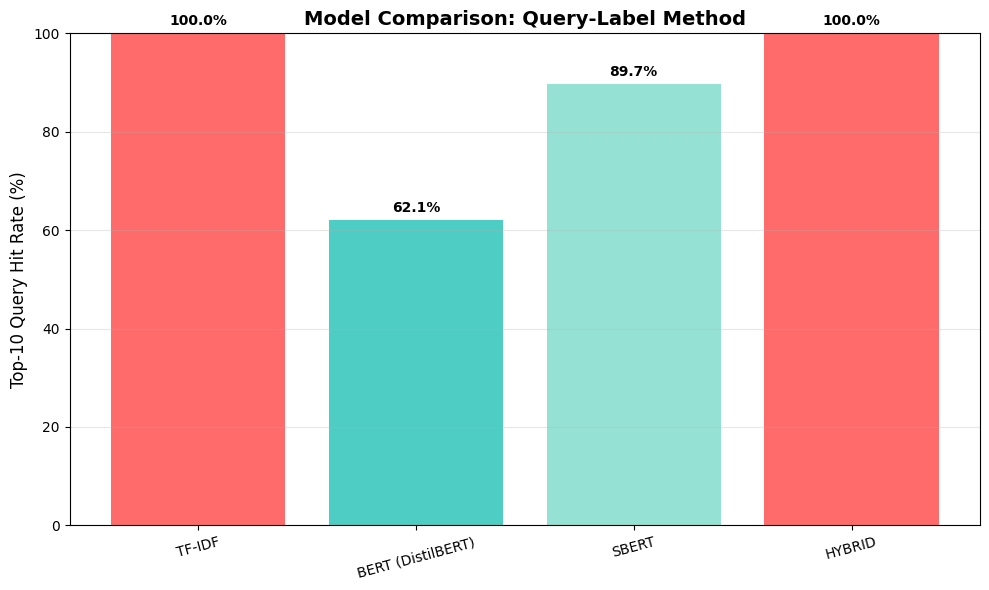


Best Models (Query-label method): TF-IDF, HYBRID (all tied with 100.0% accuracy)


In [37]:
# Bar chart showing hit rates using Query-label method 
if 'hit_rates_query' in locals():
    plt.figure(figsize=(10, 6))
    plt.bar(hit_rates_query["Model"], hit_rates_query[f"Top-{TOP_K} Query Hit Rate (%)"], 
            color=['#FF6B6B', '#4ECDC4', '#95E1D3'])
    plt.ylabel(f"Top-{TOP_K} Query Hit Rate (%)", fontsize=12)
    plt.title("Model Comparison: Query-Label Method", fontsize=14, fontweight='bold')
    plt.xticks(rotation=15)
    plt.ylim(0, 100)
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(hit_rates_query[f"Top-{TOP_K} Query Hit Rate (%)"]):
        plt.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

    best_score = hit_rates_query[f"Top-{TOP_K} Query Hit Rate (%)"].max()
    best_models = hit_rates_query[hit_rates_query[f"Top-{TOP_K} Query Hit Rate (%)"] == best_score]["Model"].tolist()
    if len(best_models) == 1:
        print(f"\nBest Model (Query-label method): {best_models[0]} with {best_score:.1f}% accuracy")
    else:
        print(f"\nBest Models (Query-label method): {', '.join(best_models)} (all tied with {best_score:.1f}% accuracy)")
else:
    print(" Please run the evaluation cell first to generate hit_rates_query")

## Save Results
Save all results to CSV files for later analysis.

In [39]:
# Save results to CSV files
if 'compare_top10' in locals():
    compare_top10.to_csv("merged_one_resume_top10.csv", index=False)

if 'results_df' in locals():
    results_df.to_csv("merged_all_resumes_top1.csv", index=False)

if 'eval_df' in locals():
    eval_df.to_csv("merged_evaluation_results.csv", index=False)

if 'hit_rates' in locals():
    hit_rates.to_csv("merged_hit_rates.csv", index=False)

if 'summary_sim' in locals():
    summary_sim.to_csv("merged_similarity_summary.csv")

if 'summary_time' in locals():
    summary_time.to_csv("merged_runtime_summary.csv")

print("All results saved to CSV files successfully!")

All results saved to CSV files successfully!
